In [117]:
# Importing the Dependencies
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix

In [118]:
# Loading the MNIST data from keras.datasets
(x_train, y_train),(x_test, y_test) = mnist.load_data()

In [119]:
type(x_train)

numpy.ndarray

In [120]:
# shape of the numpy arrays
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(60000, 28, 28) (10000, 28, 28) (60000,) (10000,)


* Training data = 60,000 images
* Test data = 10,000 images

In [122]:
# Image dimension -> 28 x 28
# Grayscale Image -> 1 channel

In [123]:
# print the 10th image 
print(x_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

In [124]:
print(x_train[10].shape)

(28, 28)


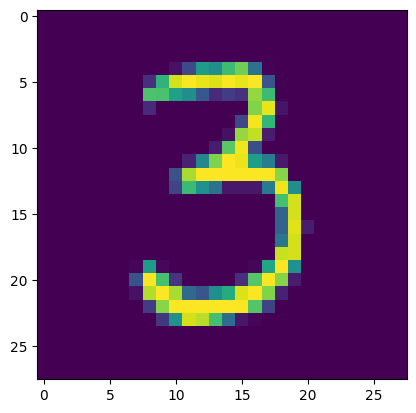

3


In [125]:
# displaying the image
plt.imshow(x_train[50])
plt.show()

# print the corresponding label
print(y_train[50])

Image Lables

In [127]:
print(y_train.shape, y_test.shape)

(60000,) (10000,)


In [128]:
# unique values in y_train
print(np.unique(y_train))

# unique values in y_test
print(np.unique(y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


We can use these labels as such or we can also apply One Hot Encoding

All the images have the same dimensions in this dataset. If not, we have to resize all the images to a common dimension

In [131]:
# Scaling the values
x_train = x_train/255
x_test = x_test/255

# ( 0/255 = 0   ,  255/255 = 1.   That means we can set all the values between 0 and 1)

In [132]:
print(x_train[10])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

# Building the Neural Network

In [134]:
# setting up the layers of the Neural Network
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(50, activation = 'relu'),
    keras.layers.Dense(50, activation = 'relu'),
    keras.layers.Dense(10, activation = 'sigmoid')
])

C:\Anaconda\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [135]:
# compiling the Neural Network
model.compile(optimizer = 'adam',
             loss = 'sparse_categorical_crossentropy',
             metrics = ['accuracy'])

In [136]:
# training the Neural Network
model.fit(x_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9128 - loss: 0.2980
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9573 - loss: 0.1424
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9680 - loss: 0.1044
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9744 - loss: 0.0830
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9793 - loss: 0.0675
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9833 - loss: 0.0558
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9857 - loss: 0.0475
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9876 - loss: 0.0405
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9888 - loss: 0.0356
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9896 - loss: 0.0314


Training data accuracy = 98.9%

In [138]:
# Accuracy on Test data:
loss, accuracy = model.evaluate(x_test, y_test)
print(accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9685 - loss: 0.1309
0.968500018119812


Testing data accuracy = 97.04%

In [140]:
print(x_test.shape)

(10000, 28, 28)


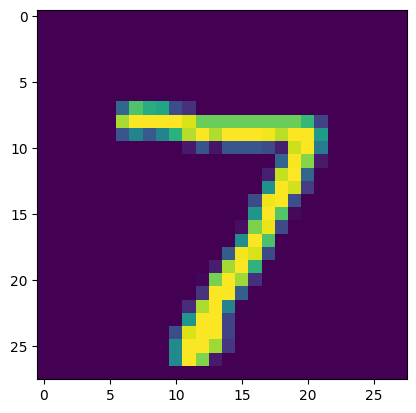

In [141]:
# first data point in x_test
plt.imshow(x_test[0])
plt.show()

In [142]:
print(y_test[0])

7


In [143]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [144]:
print(y_pred.shape)

(10000, 10)


In [145]:
print(y_pred[0])

[2.21451418e-03 2.05872604e-03 2.05650833e-02 6.94753170e-01
 1.76163278e-10 6.74778782e-03 1.45119669e-12 9.99958992e-01
 1.18935655e-04 3.77288018e-03]


* model.predict() gives the prediction probability of each calss for that data point

In [147]:
# converting the prediction probabilities to class label
label_for_first_image = np.argmax(y_pred[0])
print(label_for_first_image)

7


In [148]:
# converting teh prediction probabilities to class label for all test data points
y_pred_labels = [np.argmax(i) for i in y_pred]
print(y_pred_labels)

[7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5, 4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 3, 1, 1, 7, 4, 2, 3, 5, 1, 2, 4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 5, 3, 7, 4, 6, 4, 3, 0, 7, 0, 2, 9, 1, 7, 3, 2, 9, 7, 7, 6, 2, 7, 8, 4, 7, 3, 6, 1, 3, 6, 9, 3, 1, 4, 1, 7, 6, 9, 6, 0, 5, 4, 5, 9, 2, 1, 9, 4, 8, 7, 3, 9, 7, 4, 4, 4, 9, 2, 5, 4, 7, 6, 7, 9, 0, 5, 8, 5, 6, 6, 5, 7, 8, 1, 0, 1, 6, 4, 6, 7, 3, 1, 7, 1, 8, 2, 0, 2, 9, 8, 5, 5, 1, 5, 6, 0, 3, 4, 4, 6, 5, 4, 6, 5, 4, 5, 1, 4, 4, 7, 2, 3, 2, 7, 1, 8, 1, 8, 1, 8, 5, 0, 8, 9, 2, 5, 0, 1, 1, 1, 0, 9, 0, 3, 1, 6, 4, 2, 3, 6, 1, 1, 1, 3, 9, 5, 2, 9, 4, 5, 9, 3, 9, 0, 3, 6, 5, 5, 7, 2, 2, 7, 1, 2, 8, 4, 1, 7, 3, 3, 8, 8, 7, 9, 2, 2, 4, 1, 5, 9, 8, 7, 2, 3, 0, 2, 4, 2, 4, 1, 9, 5, 7, 7, 2, 8, 2, 6, 8, 5, 7, 7, 9, 1, 8, 1, 8, 0, 3, 0, 1, 9, 3, 4, 1, 8, 2, 1, 2, 9, 7, 5, 9, 2, 6, 4, 1, 5, 8, 2, 9, 2, 0, 4, 0, 0, 2, 8, 4, 7, 1, 2, 4, 0, 2, 7, 4, 3, 3, 0, 0, 3, 1, 9, 6, 5, 2, 5, 8, 7, 9, 3, 9, 4, 2, 0, 7, 1, 1, 2, 1, 

In [149]:
print(y_pred)

[[2.21451418e-03 2.05872604e-03 2.05650833e-02 ... 9.99958992e-01
  1.18935655e-04 3.77288018e-03]
 [1.98008176e-02 9.82270420e-01 1.00000000e+00 ... 1.42956856e-06
  1.67173557e-02 6.57989722e-13]
 [5.22044957e-06 9.99251485e-01 6.73125759e-02 ... 4.24867362e-01
  1.53167754e-01 7.77255185e-03]
 ...
 [1.46962273e-08 5.36120837e-08 3.52546015e-09 ... 1.20849777e-02
  1.19880833e-01 7.75274038e-01]
 [6.05092794e-07 7.09445681e-04 1.41186391e-07 ... 3.49190509e-06
  9.99925554e-01 4.48970028e-10]
 [7.38612376e-03 7.68027597e-09 3.40408063e-03 ... 3.66553619e-12
  5.90155969e-06 7.32382992e-04]]


* y_test        -> True Labels
* y_pred_labels -> Predicted Labels

# Confusion Matrix

In [152]:
conf_mat = confusion_matrix(y_test, y_pred_labels)

In [153]:
print(conf_mat)

tf.Tensor(
[[ 945    0    2    1    9    4    3    0    5   11]
 [   0 1110    2    4    2    0    3    3   11    0]
 [   3    0 1004    6    4    0    2    2   11    0]
 [   0    0   10  983    2    3    0    3    5    4]
 [   0    0    4    0  962    0    3    4    2    7]
 [   1    0    1   19    4  846    2    1   16    2]
 [   2    2    3    0    6    4  935    0    6    0]
 [   1    0   16    3    3    1    0  984    9   11]
 [   0    0    5    4    3    1    1    0  958    2]
 [   0    2    0    8   19    5    1    3   11  960]], shape=(10, 10), dtype=int32)


Text(0.5, 47.7222222222222, 'Predicted Labels')

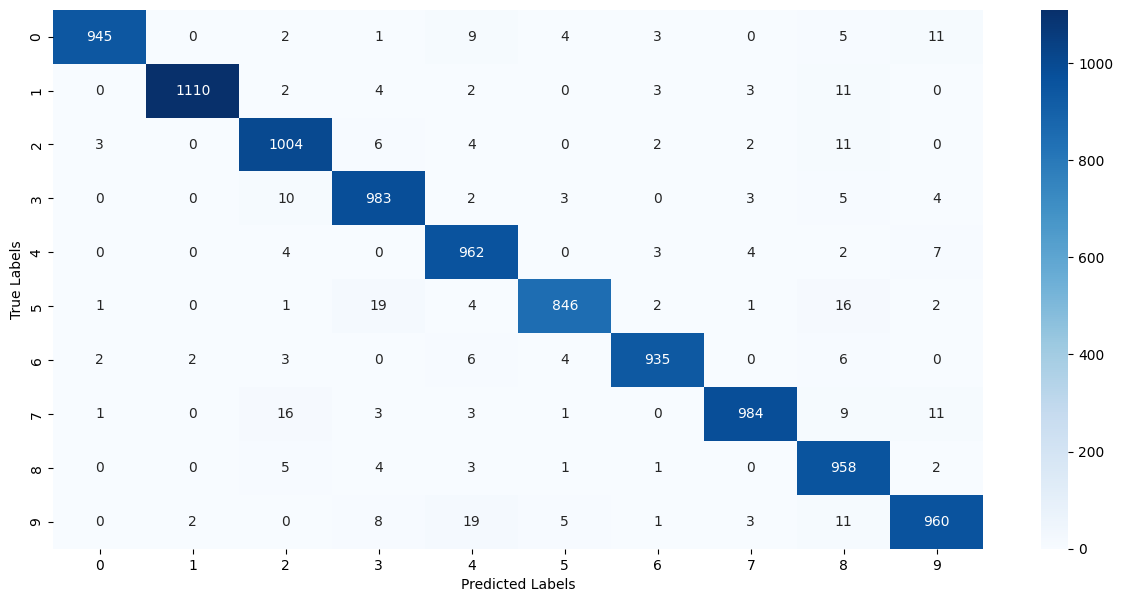

In [154]:
plt.figure(figsize=(15,7))
sns.heatmap(conf_mat, annot = True, fmt='d', cmap = 'Blues')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')

# Building a predictive system

In [156]:
input_image_path = 'number.jpg'
input_image = cv2.imread(input_image_path)

In [157]:
type(input_image)

numpy.ndarray

In [158]:
print(input_image)

[[[1 1 1]
  [1 1 1]
  [1 1 1]
  ...
  [1 1 1]
  [1 1 1]
  [1 1 1]]

 [[1 1 1]
  [1 1 1]
  [1 1 1]
  ...
  [1 1 1]
  [1 1 1]
  [1 1 1]]

 [[1 1 1]
  [1 1 1]
  [1 1 1]
  ...
  [1 1 1]
  [1 1 1]
  [1 1 1]]

 ...

 [[1 1 1]
  [1 1 1]
  [1 1 1]
  ...
  [1 1 1]
  [1 1 1]
  [1 1 1]]

 [[1 1 1]
  [1 1 1]
  [1 1 1]
  ...
  [1 1 1]
  [1 1 1]
  [1 1 1]]

 [[1 1 1]
  [1 1 1]
  [1 1 1]
  ...
  [1 1 1]
  [1 1 1]
  [1 1 1]]]


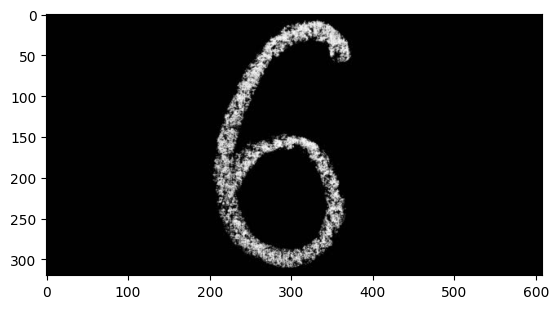

In [159]:
plt.imshow(input_image)
plt.show()

In [160]:
input_image.shape

(320, 608, 3)

In [161]:
grayscale_image = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

In [162]:
type(grayscale_image)

numpy.ndarray

In [163]:
grayscale_image.shape

(320, 608)

In [164]:
input_image_resize = cv2.resize(grayscale_image, (28,28))

In [165]:
input_image_resize.shape

(28, 28)

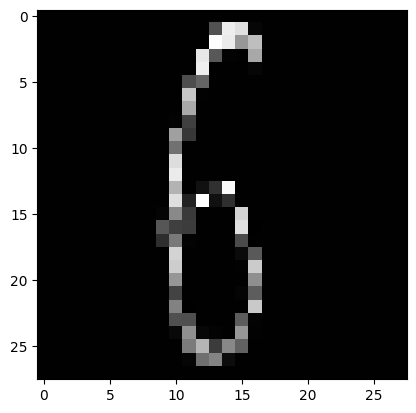

In [166]:
plt.imshow(input_image_resize, cmap='gray')
plt.show()

In [167]:
input_image_resize = input_image_resize/255

In [168]:
image_reshaped = np.reshape(input_image_resize, [1,28,28])

In [169]:
input_prediction =  model.predict(image_reshaped)
print(input_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
[[5.6065081e-05 9.5400202e-01 2.1046428e-01 4.7635238e-04 2.5276847e-02
  8.1858593e-01 9.9824321e-01 1.0196506e-02 7.0116752e-01 1.6872500e-03]]


In [170]:
input_pred_label = np.argmax(input_prediction)

In [171]:
print(input_pred_label)

6


# Predictive System

Enter the name of the image file :  number1.jpg


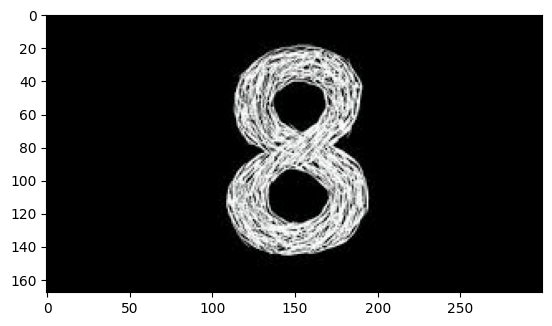

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
The Handwritten Digit is recognized as  8


In [220]:
input_image_path = input('Enter the name of the image file : ')

input_image = cv2.imread(input_image_path)

plt.imshow(input_image)
plt.show()

grayscale_image = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

input_image_resize = cv2.resize(grayscale_image, (28,28))

input_image_resize = input_image_resize/255

image_reshaped = np.reshape(input_image_resize, [1,28,28])

input_prediction =  model.predict(image_reshaped)

input_pred_label = np.argmax(input_prediction)

print("The Handwritten Digit is recognized as ",input_pred_label)